## Implementation of the ResNet 

Creating mechanisms for adapting Satellite Images and its bands into a ResNet architecture, while preserving its original size instead of using interpolation and resizing of image

In [1]:
import torch
from src.loader.reader import LDMBReader, Dataset_BigEarthNet
from src.utils.utils import load_config
import pandas as pd
from torch import nn
import numpy as np

In [2]:

config_path = "src/config/config.yaml"
config_dataset = load_config(config_path)

In [3]:
paths= {
    'path_dataset_lmdb':config_dataset["datasets"]["lmdb"],
    'path_metadata_parquet':config_dataset["datasets"]["metadata_parquet"],
    'path_metadata_snow_cloud_parquet':config_dataset["datasets"]["metadata_snow_cloud_parquet"]
}


In [4]:
tryier = LDMBReader(
    image_lmdb_file= config_dataset["datasets"]["lmdb"],
    metadata_file = config_dataset["datasets"]["metadata_parquet"],
    metadata_snow_cloud_file= config_dataset["datasets"]["metadata_snow_cloud_parquet"],
    bands= ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12"],
    small_batch=0.1
)

df_parquet = pd.read_parquet(config_dataset['datasets']['metadata_parquet'])

2025-08-13 07:26:23.660 | INFO     | src.loader.reader:__init__:246 - Merged metadata with snow/cloud metadata
2025-08-13 07:26:23.796 | INFO     | src.loader.reader:__init__:252 - Loaded 549488 labels


In [ ]:
trsys = torch.randn(3,120,120)[]
trsys

tensor([[[-0.3402,  1.0035, -0.9728,  ..., -0.6978,  0.3828,  1.1914],
         [ 2.0140, -0.8106,  0.8467,  ..., -0.4570,  0.2978, -0.2259],
         [-0.8822, -0.0706, -1.0631,  ..., -0.1138,  0.9739,  0.5106],
         ...,
         [ 0.7137, -0.9858, -1.1045,  ..., -0.5029, -0.8825, -0.2814],
         [-0.6216,  1.0944, -0.8322,  ..., -0.0106, -0.8672,  0.7631],
         [ 0.4346, -1.0068,  0.4015,  ...,  2.2603, -0.6197, -1.1454]],

        [[ 0.0082, -0.5002,  2.0130,  ...,  0.5342,  0.4033,  0.0091],
         [ 0.1498, -2.2012, -1.7274,  ..., -0.2563, -0.0359,  0.1857],
         [ 0.3544,  0.3449,  0.1403,  ...,  0.6895, -0.4411, -2.3805],
         ...,
         [ 0.2583, -1.3709, -0.3507,  ..., -1.1109, -0.8626,  0.3338],
         [ 0.3952,  0.2650, -0.4093,  ...,  1.3829,  0.8770, -1.1009],
         [-3.0153, -0.7443,  1.6092,  ..., -1.2312, -0.6500, -1.3389]],

        [[ 1.4274, -0.6848, -2.3518,  ...,  1.0480,  0.5818,  0.1799],
         [ 1.1086, -1.3004, -0.7471,  ...,  1

In [93]:
class convBlock(nn.Module):
    def __init__(self, in_channel, out_channel, padding=1, kernel_size=3, stride=1):
        super().__init__()
        self.conv = nn.Conv2d(in_channels=in_channel, out_channels=out_channel,
                              kernel_size=(kernel_size,kernel_size),
                              padding=padding, stride=stride)
        self.bn = nn.BatchNorm2d(out_channel)
        self.activation = nn.ReLU()
        self.max_pool = nn.MaxPool2d(3)

    def forward(self,x):
        print(x.shape)
        x = self.conv(x)
        print(x.shape)
        x = self.bn(x)
        print(x.shape)
        x = self.activation(x)
        print(x.shape)
        x = self.max_pool(x)
        print(x.shape)
        return x


class DoubleConvBlock(nn.Module):
    def __init__(self, in_channel, out_channel, padding=1, kernel_size=3, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channel, out_channels=out_channel,
                              kernel_size=(kernel_size, kernel_size),
                              padding=padding, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.activation1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(in_channels=out_channel, out_channels=out_channel, 
                              kernel_size=(kernel_size, kernel_size), padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channel)
        self.activation2 = nn.ReLU()

    def forward(self, x):
        print('shape x input:',x.shape)
        x = self.conv1(x)
        print('after first conv',x.shape)
        x = self.bn1(x)
        x = self.activation1(x)
        
        x = self.conv2(x)
        print('after second conv:',x.shape)
        x = self.bn2(x)
        x = self.activation2(x)
        return x
    
class alt_DoubleConvBlock(nn.Module):
    def __init__(self, in_channel, out_channel, padding=1, kernel_size=3, stride=1):
        super().__init__()
        self.double_conv = nn.Sequential(
                nn.Conv2d(in_channels=in_channel, out_channels=out_channel,
                            kernel_size=(kernel_size, kernel_size),
                            padding=padding, stride=stride),
            nn.BatchNorm2d(out_channel),
            nn.ReLU(),
            nn.Conv2d(in_channels=out_channel, out_channels=out_channel, 
                            kernel_size=(kernel_size, kernel_size), padding=padding),
            nn.BatchNorm2d(out_channel),
            nn.ReLU()
        )
        self.max_pool = nn.MaxPool2d(2)

    def forward(self, x):
        print('x input:',x.shape)
        x = self.double_conv(x)
        print('after double conv:', x.shape)
        x = self.max_pool(x)
        print('after max pool',x.shape)
        return x
        
    


In [94]:
test = alt_DoubleConvBlock(in_channel=3,out_channel=16).forward(tensor)

x input: torch.Size([1, 3, 120, 120])
after double conv: torch.Size([1, 16, 120, 120])
after max pool torch.Size([1, 16, 60, 60])


In [ ]:
class DoubleConvBlock(nn.Module):
    def __init__(self, in_channel, out_channel, padding=1, kernel_size=3, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels=in_channel, out_channels=out_channel,
                              kernel_size=(kernel_size, kernel_size),
                              padding=padding, stride=stride)
        self.bn1 = nn.BatchNorm2d(out_channel)
        self.activation1 = nn.ReLU()
        
        self.conv2 = nn.Conv2d(in_channels=out_channel, out_channels=out_channel, 
                              kernel_size=(kernel_size, kernel_size), padding=padding)
        self.bn2 = nn.BatchNorm2d(out_channel)
        self.activation2 = nn.ReLU()

    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.activation1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.activation2(x)
        return x

class Unet(nn.Module):
    def __init__(self,in_channel, num_classes,downsampling_size=2):
        super(Unet,self).__init__()

        ## Max Polling with fixed max_pool
        self.max_pool2d = nn.MaxPool2d(downsampling_size=downsampling_size)

        # Encoding
        self.downconv1 = DoubleConvBlock(in_channel=in_channel, out_channel=64) 
        self.downconv2 = DoubleConvBlock(in_channel=64, out_channel=128) 
        self.downconv3 = DoubleConvBlock(in_channel=128, out_channel=256)
        self.downconv4 = DoubleConvBlock(in_channel=256, out_channel=512)
        self.downconv5 = DoubleConvBlock(in_channel=512, out_channel=1024)

        ## Decoding
        self.up_transpose5 = nn.ConvTranspose2d(in_channels=1024, out_channels=512,kernel_size=2,stride=2)
        self.upconv5 = DoubleConvBlock(in_channels=1024, out_channels=512)
        self.up_transpose4 = nn.ConvTranspose2d(in_channels=512, out_channels=256, kernel_size=2, stride=2)
        self.upconv4 = DoubleConvBlock(in_channel=512, out_channel=256)
        self.up_transpose3 = nn.ConvTranspose2d(in_channels=256, out_channels=128, kernel_size=2, stride=2)
        self.upconv3 = DoubleConvBlock(in_channel=256, out_channel=128)
        self.up_transpose2 = nn.ConvTranspose2d(in_channels=128, out_channels=64, kernel_size=2, stride=2)
        self.upconv2 = DoubleConvBlock(in_channel=128, out_channel=64)
        self.out = DoubleConvBlock(in_channel=64, out_channel=num_classes)

    def forward(self,x):
        down1 = self.downconv1(x)
        down2 = self.max_pool2d(x)
        down3 = self.downconv2(x)
        down4 = self.max_pool2d(x)
        down5 = self.downconv3(x)
        down6 = self.max_pool2d(x)
        down7 = self.downconv4(x)
        down8 = self.max_pool2d(x)
        down9 = self.downconv5(x)
        

        ## Up
        up1 = self.up_transpose5(down9)
        x = self.upconv5(torch.cat([down7, up1],1))
        up2 = self.up_transpose4(x)
        x = self.upconv4(torch.cat([up2, down5],1))
        up3 = self.up_transpose3(x)
        x = self.upconv3(torch.cat([up3, down3]))
        up4 = self.up_transpose2(x)
        x = self.upconv2(torch.cat([up4,down1]))

        out = self.out(x)
        return out





    





In [31]:
test

alt_DoubleConvBlock(
  (double_conv): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU()
  )
)

In [25]:
class EncoderBlock(nn.Module):        
    # Consists of Conv -> ReLU -> MaxPool
    def __init__(self, in_chans, out_chans, layers=2, sampling_factor=2, padding="same"):
        super().__init__()
        self.encoder = nn.ModuleList()
        self.encoder.append(nn.Conv2d(in_chans, out_chans, 3, 1, padding=padding))
        self.encoder.append(nn.ReLU())
        for _ in range(layers-1):
            self.encoder.append(nn.Conv2d(out_chans, out_chans, 3, 1, padding=padding))
            self.encoder.append(nn.ReLU())
        self.mp = nn.MaxPool2d(sampling_factor)
    def forward(self, x):
        for enc in self.encoder:
            x = enc(x)
        mp_out = self.mp(x)
        return mp_out, x

In [26]:
test = EncoderBlock(3,16,layers=4)

In [27]:
test.encoder

ModuleList(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (1): ReLU()
  (2): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (3): ReLU()
  (4): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (5): ReLU()
  (6): Conv2d(16, 16, kernel_size=(3, 3), stride=(1, 1), padding=same)
  (7): ReLU()
)

In [39]:
inp = torch.rand((2,3,120,120))
out = convBlock(in_channel=3, out_channel=16, stride=2).forward(tensor.unsqueeze(0).float())


torch.Size([1, 3, 120, 120])
torch.Size([1, 16, 60, 60])
torch.Size([1, 16, 60, 60])
torch.Size([1, 16, 60, 60])
torch.Size([1, 16, 20, 20])


In [28]:
out.shape

torch.Size([2, 6, 120, 120])

In [37]:
out[1].shape

torch.Size([6, 120, 120])

In [6]:
import torchshow

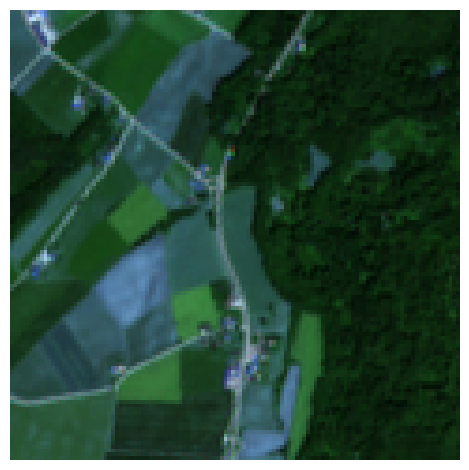

In [12]:
torchshow.show(tensor)

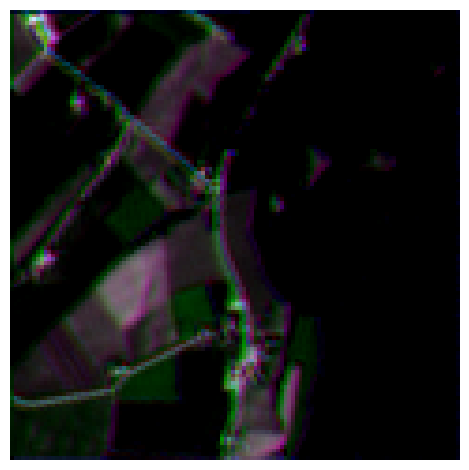

In [22]:
torchshow.show(out)

def conv_block(input, num_filters):

In [119]:
sums =  [-0.0622, -0.0207, -0.0630, -0.0441, -0.0634, -0.0447, -0.0311, -0.0597,
         -0.0553, -0.0607, -0.0300, -0.0062, -0.0184, -0.0622, -0.0631, -0.0389,
         -0.0621, -0.0436, -0.0484]

In [120]:
np.array(sums).sum()

-0.8777999999999999

In [109]:
t = torch.from_numpy(np.array(sums))

In [104]:
t[t>=0.5,1,0]

IndexError: too many indices for tensor of dimension 1

In [112]:
(t>0.5).float()

tensor([0., 0., 0., 0., 0., 1., 0., 0., 1., 1., 0., 0., 1., 0., 1., 1., 0., 1.,
        1.])